In [8]:
import numpy as np
import matplotlib.pyplot as plt

**Exercise 4.2.1**

In each case, show that the given $g(x)$ has a fixed point at the given $p$ and use (4.2.3) to show that fixed-point iteration can converge to it.

(a) $g(x)=1+x-1/9x^2$, $p=3$

$g(3)=1+3-1/9(3)^2=3$, so $p$ is a fixed point.

$g'(x)=1-2/9x$, $|g'(3)|=|1-2/3|=1/3<1$, so fixed-point iteration can converge to it.

(b) $g(x)=\pi+1/4\sin(x)$. $p=\pi$

$g(\pi)=\pi+1/4\sin(\pi)=\pi$, so $p$ is a fixed point.

$g'(x)=1/4\cos(x)$, $|g'(\pi)|=|1/4\cos(\pi)|=1/4<1$, so fixed-point iteration can converge to it.

(c) $g(x)=x+1-\tan(x/4)$, $p=\pi$

$g(\pi)=\pi+1-\tan(\pi/4)=\pi$, so $p$ is a fixed point.

$g'(x)=1-1/4\sec^2(x/4),|g'(\pi)|=|1-1/4*2|=1/2<1$, so fixed-point iteration can converge to it.

**Exercise 4.2.2**

For each case in the preceding problem, apply 25 fixed-point iterations starting from $x_1=1$. Make a log-linear plot of the error to verify linear convergence. Then, use numerical values of the error to determine an approximate value for $\sigma$ in (4.2.4).

In [24]:
def fixed_point_iteration(g, x_0 = 1.0):
    x = np.zeros(25)
    x[0] = x_0
    for i in range(25 - 1):
        x[i + 1] = g(x[i])
    return x

def log_linear_error_plot(x, p):
    err = abs(x - p)

    linear_fit = np.polyfit(np.arange(5, 25 + 1), np.log(err[4:]), 1)
    sigma = np.exp(linear_fit[0])

    plt.semilogy(err, "-o")
    plt.xlabel("Iteration number")
    plt.ylabel("Error")
    plt.show()

    print(f"sigma = {sigma}")

(a)

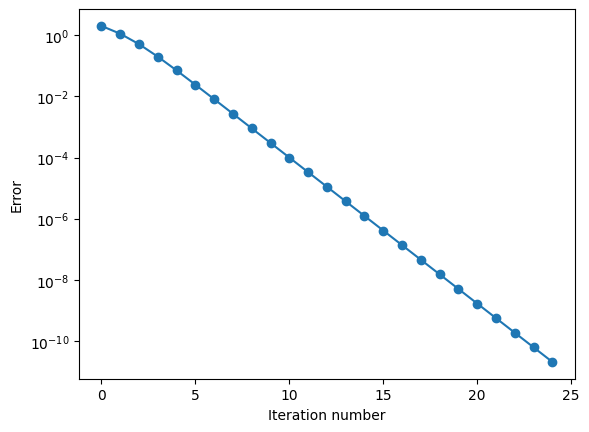

sigma = 0.3335518443031522


In [14]:
def g(x):
    return 1 + x - (1 / 9) * (x ** 2)

x = fixed_point_iteration(g)
log_linear_error_plot(x, 3)



(b)

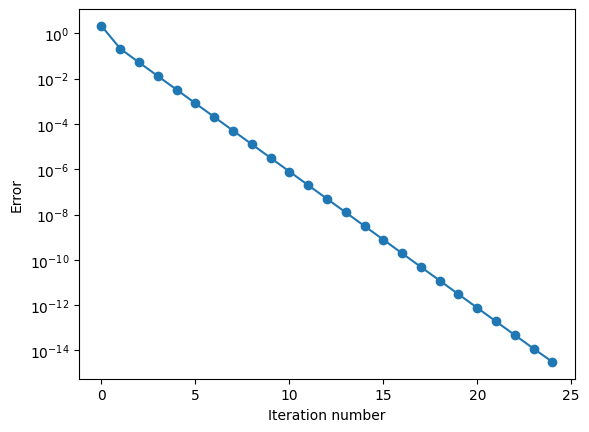

sigma = 0.250189718740918


In [15]:
def g(x):
    return np.pi + (1 / 4) * np.sin(x)

x = fixed_point_iteration(g)
log_linear_error_plot(x, np.pi)

(c)

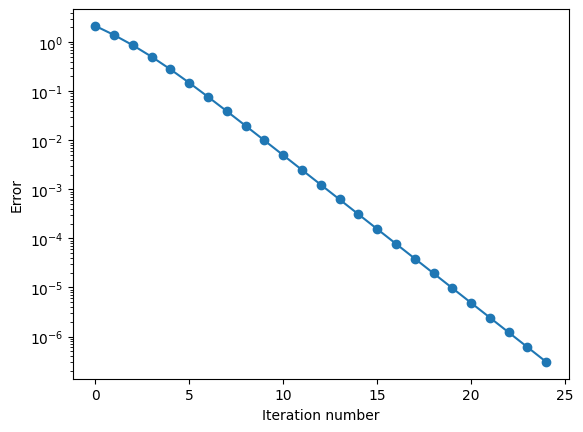

sigma = 0.5016508694057623


In [16]:
def g(x):
    return x + 1 - np.tan(x / 4)

x = fixed_point_iteration(g)
log_linear_error_plot(x, np.pi)

**Exercise 4.2.6**

(a) Show that $p=1/3$ is a fixed point of $g(x)=2x-3x^2$.

$g(1/3)=2(1/3) - 3(1/3)^2=2/3-1/3=1/3$, so $p$ is a fixed-point.

(b) Find $g'(1/3)$. How does this affect (4.2.3)?

$g'(x)=2-6x$, $g'(1/3)=2-6/3=0$.

To arrive at (4.2.3), we make the approximation $g(p+\epsilon_k)\approx p+\epsilon_k g'(p)$. If $g'(x)=0$, it would seem to follow that $g(p+\epsilon_k)\approx p$.

(c) Do an experiment with fixed-point iteration on $g$ to converge to $p=1/3$. Is the convergence a straight line on a log-linear plot?

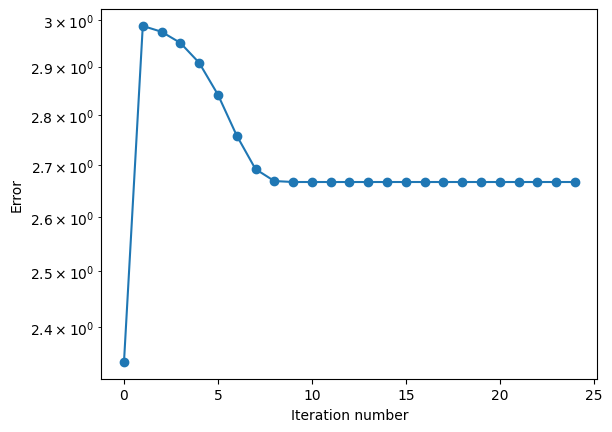

sigma = 0.9976952174153798


In [40]:
def g(x):
    return 2 * x - 3 * (x ** 2)

x = fixed_point_iteration(g, x_0 = 0.66)
log_linear_error_plot(x, 3)

It seems like $x_0>0.66$ causes the iteration to not converge. Interesting... It's definitely not a straight line (unless you count a line with slope $0$, haha).

**Exercise 4.2.7**

Consider the iteration

$$x_{k+1}=x_k-\frac{f(x_k)}{c},k=0,1,\dots$$

Suppose $f(p)=0$ and that $f'(p)>0$ exists. Find one or more conditions on $c$ such that the iteration converges to $p$.